In [1]:
!pip install -q "qiskit>=1.0,<2.0" "qiskit-aer>=0.14,<1.0" "qiskit-optimization>=0.6,<1.0" numpy pandas matplotlib scipy

In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import defaultdict
from typing import Dict, Tuple

from scipy.optimize import minimize

import qiskit
import qiskit_aer
import qiskit_optimization

from qiskit.circuit.library import QAOAAnsatz
from qiskit.primitives import BackendEstimatorV2, BackendSamplerV2
from qiskit_aer import AerSimulator
from qiskit_optimization import QuadraticProgram
from qiskit_optimization.converters import QuadraticProgramToQubo

np.random.seed(7)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
plt.style.use("seaborn-v0_8-whitegrid")

print("Qiskit version:", qiskit.__version__)
print("Qiskit Aer version:", qiskit_aer.__version__)
print("Qiskit Optimization version:", qiskit_optimization.__version__)

Qiskit version: 1.4.5
Qiskit Aer version: 0.17.2
Qiskit Optimization version: 0.7.0


In [3]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import defaultdict
from typing import Dict, Tuple
from scipy.optimize import minimize

import qiskit
import qiskit_aer
import qiskit_optimization

from qiskit_aer import AerSimulator
from qiskit.primitives import BackendEstimatorV2, BackendSamplerV2
from qiskit.circuit.library import QAOAAnsatz
from qiskit_optimization import QuadraticProgram
from qiskit_optimization.converters import QuadraticProgramToQubo

In [4]:
num_jobs = 5
num_nodes = 5
job_weights = [15, 30, 10, 45, 20]

total_weight = float(sum(job_weights))
target_load = total_weight / num_nodes
num_qubits = num_jobs * num_nodes

jobs_df = pd.DataFrame({
    "Job": [f"Job {j}" for j in range(num_jobs)],
    "Weight": job_weights
})

display(jobs_df)

print(f"Number of jobs       : {num_jobs}")
print(f"Number of nodes      : {num_nodes}")
print(f"Binary variables     : {num_qubits}")
print(f"Total workload       : {total_weight}")
print(f"Perfect target load  : {target_load:.2f} per node")

,Job,Weight
0,Job 0,15
1,Job 1,30
2,Job 2,10
3,Job 3,45
4,Job 4,20


Number of jobs       : 5
Number of nodes      : 5
Binary variables     : 25
Total workload       : 120.0
Perfect target load  : 24.00 per node


In [5]:
def build_load_balancing_quadratic_program(
    num_jobs: int,
    num_nodes: int,
    job_weights: list[float],
) -> tuple[QuadraticProgram, Dict[Tuple[int, int], str], list[str]]:
    """
    Build a QuadraticProgram for HPC load balancing.

    Decision variable:
        x[j, n] = 1 if job j is assigned to node n, else 0

    Objective:
        minimize sum_n (load_n - target_load)^2

    Constraint:
        each job must be assigned to exactly one node
    """
    if num_jobs <= 0:
        raise ValueError("num_jobs must be positive.")
    if num_nodes <= 0:
        raise ValueError("num_nodes must be positive.")
    if len(job_weights) != num_jobs:
        raise ValueError("len(job_weights) must equal num_jobs.")

    qp = QuadraticProgram("hpc_load_balancing_5x5")

    x: Dict[Tuple[int, int], str] = {}
    ordered_vars: list[str] = []

    for j in range(num_jobs):
        for n in range(num_nodes):
            var_name = f"x_{j}_{n}"
            qp.binary_var(name=var_name)
            x[(j, n)] = var_name
            ordered_vars.append(var_name)

    total_weight = float(sum(job_weights))
    target_load = total_weight / float(num_nodes)

    constant = 0.0
    linear = defaultdict(float)
    quadratic = defaultdict(float)

    for n in range(num_nodes):
        constant += target_load**2

        for j in range(num_jobs):
            var_jn = x[(j, n)]
            wj = float(job_weights[j])
            linear[var_jn] += (wj**2) - (2.0 * target_load * wj)

        for j in range(num_jobs):
            for k in range(j + 1, num_jobs):
                var_jn = x[(j, n)]
                var_kn = x[(k, n)]
                quadratic[(var_jn, var_kn)] += 2.0 * float(job_weights[j]) * float(job_weights[k])

    qp.minimize(
        constant=constant,
        linear=dict(linear),
        quadratic=dict(quadratic),
    )

    for j in range(num_jobs):
        qp.linear_constraint(
            linear={x[(j, n)]: 1 for n in range(num_nodes)},
            sense="==",
            rhs=1,
            name=f"assign_job_{j}",
        )

    return qp, x, ordered_vars


qp, x, ordered_vars = build_load_balancing_quadratic_program(
    num_jobs=num_jobs,
    num_nodes=num_nodes,
    job_weights=job_weights,
)

variable_grid = pd.DataFrame(
    [[x[(j, n)] for n in range(num_nodes)] for j in range(num_jobs)],
    index=[f"Job {j}" for j in range(num_jobs)],
    columns=[f"Node {n}" for n in range(num_nodes)],
)

display(variable_grid)

print(f"Quadratic program name   : {qp.name}")
print(f"Binary variables         : {len(ordered_vars)}")
print(f"Linear constraints       : {len(qp.linear_constraints)}")

,Node 0,Node 1,Node 2,Node 3,Node 4
Job 0,x_0_0,x_0_1,x_0_2,x_0_3,x_0_4
Job 1,x_1_0,x_1_1,x_1_2,x_1_3,x_1_4
Job 2,x_2_0,x_2_1,x_2_2,x_2_3,x_2_4
Job 3,x_3_0,x_3_1,x_3_2,x_3_3,x_3_4
Job 4,x_4_0,x_4_1,x_4_2,x_4_3,x_4_4


Quadratic program name   : hpc_load_balancing_5x5
Binary variables         : 25
Linear constraints       : 5


In [6]:

from qiskit_optimization.converters import QuadraticProgramToQubo

converter = QuadraticProgramToQubo(penalty=120.0)
qubo = converter.convert(qp)

ising_operator, ising_offset = qubo.to_ising()

print("QUBO conversion complete.")
print(f"QUBO variables      : {len(qubo.variables)}")
print(f"Ising qubits        : {ising_operator.num_qubits}")
print(f"Ising energy offset : {ising_offset:.4f}")

QUBO conversion complete.
QUBO variables      : 25
Ising qubits        : 25
Ising energy offset : 13142.5000


In [7]:
print("qp defined:", "qp" in globals())
print("qubo defined:", "qubo" in globals())
print("ising_operator defined:", "ising_operator" in globals())

qp defined: True
qubo defined: True
ising_operator defined: True


In [8]:

import time
import numpy as np
from scipy.optimize import minimize

from qiskit import transpile
from qiskit_aer import AerSimulator
from qiskit.primitives import BackendEstimatorV2, BackendSamplerV2
from qiskit.circuit.library import QAOAAnsatz

if "ising_operator" not in globals():
    raise RuntimeError("ising_operator is not defined. Run the QUBO-to-Ising cell first.")

backend = AerSimulator(method="statevector")
backend.set_options(seed_simulator=7)

estimator = BackendEstimatorV2(backend=backend)
sampler = BackendSamplerV2(backend=backend)

raw_ansatz = QAOAAnsatz(
    cost_operator=ising_operator,
    reps=1,
    flatten=True
)

isa_ansatz = transpile(raw_ansatz, backend=backend, optimization_level=1)

try:
    isa_observable = ising_operator.apply_layout(isa_ansatz.layout)
except Exception:
    isa_observable = ising_operator

print(f"QAOA circuit created with {isa_ansatz.num_qubits} qubits.")
print(f"Number of trainable parameters: {isa_ansatz.num_parameters}")

def quantum_cost_function(params: np.ndarray) -> float:
    pub = (isa_ansatz, isa_observable, params)
    job = estimator.run([pub])
    result = job.result()[0]
    evs = np.asarray(result.data.evs).reshape(-1)[0]
    return float(np.real(evs))

initial_params = np.zeros(isa_ansatz.num_parameters, dtype=float)

print("Running COBYLA optimization...")
start_time = time.perf_counter()

opt_result = minimize(
    quantum_cost_function,
    x0=initial_params,
    method="COBYLA",
    options={"maxiter": 8, "disp": False},
)

elapsed = time.perf_counter() - start_time
final_energy = quantum_cost_function(opt_result.x)

print("Optimization finished.")
print(f"Runtime (seconds)       : {elapsed:.2f}")
print(f"Optimizer status        : {opt_result.message}")
print(f"Best parameters         : {opt_result.x}")
print(f"Final estimated energy  : {final_energy:.6f}")

QAOA circuit created with 25 qubits.
Number of trainable parameters: 2
Running COBYLA optimization...
Optimization finished.
Runtime (seconds)       : 42.39
Optimizer status        : Maximum number of function evaluations has been exceeded.
Best parameters         : [0. 0.]
Final estimated energy  : -219.281006


In [9]:
def bitstring_to_assignment_matrix(bitstring: str, num_jobs: int, num_nodes: int) -> np.ndarray:
    """
    Convert a measured Qiskit bitstring into a (num_jobs x num_nodes) assignment matrix.

    Qiskit displays bitstrings in reverse qubit order relative to the logical
    variable creation order, so we reverse the bitstring before reshaping.
    """
    expected_len = num_jobs * num_nodes
    if len(bitstring) != expected_len:
        raise ValueError(f"Expected bitstring length {expected_len}, got {len(bitstring)}.")

    logical_bits = np.array([int(b) for b in bitstring[::-1]], dtype=int)
    return logical_bits.reshape((num_jobs, num_nodes))


def evaluate_assignment(assignment_matrix: np.ndarray, job_weights: list[float]) -> dict:
    """
    Evaluate the decoded assignment matrix.
    """
    weights = np.asarray(job_weights, dtype=float)
    loads = assignment_matrix.T @ weights
    target = float(np.sum(weights) / assignment_matrix.shape[1])
    row_sums = assignment_matrix.sum(axis=1)

    objective = float(np.sum((loads - target) ** 2))
    feasible = bool(np.all(row_sums == 1))

    return {
        "loads": loads,
        "target": target,
        "row_sums": row_sums,
        "objective": objective,
        "feasible": feasible,
    }


def select_best_sample(counts: dict, num_jobs: int, num_nodes: int, job_weights: list[float]):
    """
    Choose the best measured sample.

    Priority:
    1. feasible schedules
    2. lowest imbalance objective
    3. highest measurement count
    """
    rows = []
    total_counts = sum(counts.values())

    for bitstring, count in counts.items():
        assignment = bitstring_to_assignment_matrix(bitstring, num_jobs, num_nodes)
        metrics = evaluate_assignment(assignment, job_weights)

        rows.append({
            "Bitstring": bitstring,
            "Count": count,
            "Probability": count / total_counts,
            "Feasible": metrics["feasible"],
            "Objective": metrics["objective"],
            "RowSums": metrics["row_sums"].tolist(),
        })

    candidates_df = pd.DataFrame(rows).sort_values(
        by=["Feasible", "Objective", "Count"],
        ascending=[False, True, False]
    ).reset_index(drop=True)

    if len(candidates_df) == 0:
        raise RuntimeError("No measurement outcomes were returned by the sampler.")

    if candidates_df["Feasible"].any():
        selected = candidates_df[candidates_df["Feasible"]].iloc[0]
        note = "Selected the lowest-objective feasible solution."
    else:
        selected = candidates_df.iloc[0]
        note = "No feasible bitstring was sampled; selected the best available candidate."

    return selected, candidates_df, note


if "isa_ansatz" not in globals():
    raise RuntimeError("isa_ansatz is not defined. Run the QAOA optimization cell first.")

optimized_circuit = isa_ansatz.assign_parameters(opt_result.x)
measured_circuit = optimized_circuit.copy()
measured_circuit.measure_all()

measured_circuit = transpile(measured_circuit, backend=backend, optimization_level=1)


shots = 1024
sampler_job = sampler.run([measured_circuit], shots=shots)
sampler_result = sampler_job.result()[0]

counts = None

if hasattr(sampler_result.data, "meas"):
    counts = sampler_result.data.meas.get_counts()
else:
    try:
        data_keys = list(sampler_result.data.keys())
        if len(data_keys) == 0:
            raise RuntimeError("Sampler returned no classical registers.")
        reg_name = data_keys[0]
        counts = getattr(sampler_result.data, reg_name).get_counts()
    except Exception as exc:
        raise RuntimeError(f"Could not extract counts from sampler result: {exc}")

if counts is None or len(counts) == 0:
    raise RuntimeError("Sampler returned empty counts.")


selected_row, candidates_df, selection_note = select_best_sample(
    counts=counts,
    num_jobs=num_jobs,
    num_nodes=num_nodes,
    job_weights=job_weights,
)

best_bitstring = selected_row["Bitstring"]
assignment_matrix = bitstring_to_assignment_matrix(best_bitstring, num_jobs, num_nodes)

metrics = evaluate_assignment(assignment_matrix, job_weights)
node_loads = metrics["loads"]
constraints_ok = metrics["feasible"]


schedule_rows = []
for j in range(num_jobs):
    assigned_nodes = np.where(assignment_matrix[j] == 1)[0].tolist()

    if len(assigned_nodes) == 1:
        assigned_to = f"Node {assigned_nodes[0]}"
    elif len(assigned_nodes) == 0:
        assigned_to = "Unassigned"
    else:
        assigned_to = "Conflict"

    schedule_rows.append({
        "Job": f"Job {j}",
        "Weight": job_weights[j],
        "Assigned Node": assigned_to
    })

schedule_df = pd.DataFrame(schedule_rows)

loads_df = pd.DataFrame({
    "Node": [f"Node {n}" for n in range(num_nodes)],
    "Load": node_loads,
    "Target": [metrics["target"]] * num_nodes
})

assignment_df = pd.DataFrame(
    assignment_matrix,
    index=[f"Job {j}" for j in range(num_jobs)],
    columns=[f"Node {n}" for n in range(num_nodes)]
)


print("=" * 72)
print("QAOA SOLUTION SUMMARY")
print("=" * 72)
print(f"Best sampled bitstring      : {best_bitstring}")
print(f"Constraint satisfaction     : {constraints_ok}")
print(f"Load-balancing objective    : {metrics['objective']:.2f}")
print(selection_note)

print("\nTop sampled candidates:")
display(candidates_df.head(10))

print("\nFinal job-to-node schedule:")
display(schedule_df)

print("\nFinal node loads:")
display(loads_df)

print("\nDecoded 5x5 assignment matrix:")
display(assignment_df)

QAOA SOLUTION SUMMARY
Best sampled bitstring      : 0000100010010000000100010
Constraint satisfaction     : True
Load-balancing objective    : 3320.00
Selected the lowest-objective feasible solution.

Top sampled candidates:


,Bitstring,Count,Probability,Feasible,Objective,RowSums
0,0000100010010000000100010,1,0.000977,True,3320.0,"[1, 1, 1, 1, 1]"
1,0111000000101010000011010,1,0.000977,False,475.0,"[3, 0, 3, 0, 3]"
2,0011000000110111000101000,1,0.000977,False,565.0,"[1, 2, 4, 0, 2]"
3,1101000001101100000001100,1,0.000977,False,635.0,"[2, 0, 3, 1, 3]"
4,1000001000100100000000111,1,0.000977,False,640.0,"[3, 0, 2, 1, 1]"
5,0000000000111010001100110,1,0.000977,False,1090.0,"[2, 2, 4, 0, 0]"
6,0100000010110000010000101,1,0.000977,False,1195.0,"[2, 1, 2, 1, 1]"
7,1001100000110000010010110,1,0.000977,False,1215.0,"[3, 1, 2, 0, 3]"
8,1000000000000100010001100,1,0.000977,False,1310.0,"[2, 1, 1, 0, 1]"
9,0010001000101101000000101,1,0.000977,False,1415.0,"[2, 1, 3, 1, 1]"



Final job-to-node schedule:


,Job,Weight,Assigned Node
0,Job 0,15,Node 1
1,Job 1,30,Node 0
2,Job 2,10,Node 3
3,Job 3,45,Node 1
4,Job 4,20,Node 0



Final node loads:


,Node,Load,Target
0,Node 0,50.0,24.0
1,Node 1,60.0,24.0
2,Node 2,0.0,24.0
3,Node 3,10.0,24.0
4,Node 4,0.0,24.0



Decoded 5x5 assignment matrix:


,Node 0,Node 1,Node 2,Node 3,Node 4
Job 0,0,1,0,0,0
Job 1,1,0,0,0,0
Job 2,0,0,0,1,0
Job 3,0,1,0,0,0
Job 4,1,0,0,0,0


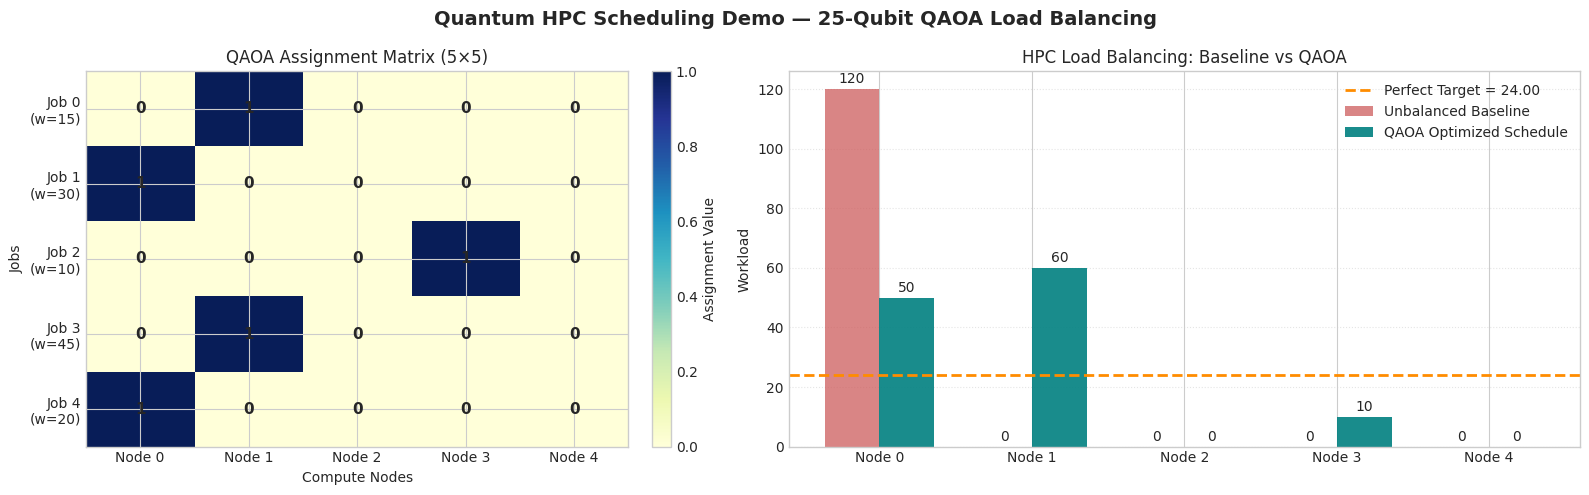

,Metric,Value
0,Total Workload,120.0
1,Target Load per Node,24.0
2,Baseline Imbalance Objective,11520.0
3,QAOA Imbalance Objective,3320.0
4,Relative Improvement (%),71.18
5,Constraint Satisfied,True


In [10]:
baseline_loads = np.zeros(num_nodes, dtype=float)
baseline_loads[0] = total_weight

baseline_objective = float(np.sum((baseline_loads - target_load) ** 2))
optimized_objective = float(metrics["objective"])
improvement_pct = 100.0 * (1.0 - (optimized_objective / baseline_objective))

fig, axes = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={"width_ratios": [1.05, 1.4]})


ax0 = axes[0]
im = ax0.imshow(assignment_matrix, cmap="YlGnBu", vmin=0, vmax=1, aspect="auto")

for i in range(num_jobs):
    for j in range(num_nodes):
        ax0.text(j, i, str(assignment_matrix[i, j]), ha="center", va="center", fontsize=11, fontweight="bold")

ax0.set_xticks(range(num_nodes))
ax0.set_xticklabels([f"Node {n}" for n in range(num_nodes)])
ax0.set_yticks(range(num_jobs))
ax0.set_yticklabels([f"Job {j}\n(w={job_weights[j]})" for j in range(num_jobs)])
ax0.set_title("QAOA Assignment Matrix (5×5)")
ax0.set_xlabel("Compute Nodes")
ax0.set_ylabel("Jobs")

cbar = fig.colorbar(im, ax=ax0, fraction=0.046, pad=0.04)
cbar.set_label("Assignment Value")


ax1 = axes[1]
x_axis = np.arange(num_nodes)
width = 0.36

bars1 = ax1.bar(
    x_axis - width / 2,
    baseline_loads,
    width=width,
    label="Unbalanced Baseline",
    color="indianred",
    alpha=0.75,
)

bars2 = ax1.bar(
    x_axis + width / 2,
    node_loads,
    width=width,
    label="QAOA Optimized Schedule",
    color="teal",
    alpha=0.90,
)

ax1.axhline(
    target_load,
    color="darkorange",
    linestyle="--",
    linewidth=2,
    label=f"Perfect Target = {target_load:.2f}"
)

for bar in list(bars1) + list(bars2):
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1.0,
        f"{height:.0f}",
        ha="center",
        va="bottom",
        fontsize=10,
    )

ax1.set_xticks(x_axis)
ax1.set_xticklabels([f"Node {n}" for n in range(num_nodes)])
ax1.set_ylabel("Workload")
ax1.set_title("HPC Load Balancing: Baseline vs QAOA")
ax1.legend()
ax1.grid(axis="y", linestyle=":", alpha=0.5)

plt.suptitle("Quantum HPC Scheduling Demo — 25-Qubit QAOA Load Balancing", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

summary_df = pd.DataFrame({
    "Metric": [
        "Total Workload",
        "Target Load per Node",
        "Baseline Imbalance Objective",
        "QAOA Imbalance Objective",
        "Relative Improvement (%)",
        "Constraint Satisfied"
    ],
    "Value": [
        total_weight,
        round(target_load, 2),
        round(baseline_objective, 2),
        round(optimized_objective, 2),
        round(improvement_pct, 2),
        constraints_ok
    ]
})

display(summary_df)

Running improved optimization (maxiter=30)...


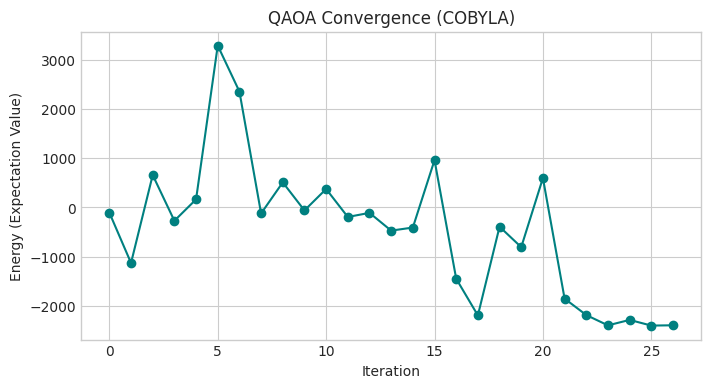

Improved Final Energy: -2397.260742


In [11]:
history = []
def tracking_cost_function(params):
    cost = quantum_cost_function(params)
    history.append(cost)
    return cost

print("Running improved optimization (maxiter=30)...")
opt_result_improved = minimize(
    tracking_cost_function,
    x0=np.random.rand(isa_ansatz.num_parameters) * 0.1,
    method='COBYLA',
    options={'maxiter': 30}
)

plt.figure(figsize=(8, 4))
plt.plot(history, marker='o', color='teal')
plt.title("QAOA Convergence (COBYLA)")
plt.xlabel("Iteration")
plt.ylabel("Energy (Expectation Value)")
plt.grid(True)
plt.show()

print(f"Improved Final Energy: {history[-1]:.6f}")

In [12]:
ansatz_p2 = QAOAAnsatz(cost_operator=ising_operator, reps=2, flatten=True)
isa_ansatz_p2 = transpile(ansatz_p2, backend=backend, optimization_level=1)

print(f"New QAOA Depth: {ansatz_p2.reps}")
print(f"Parameters to train: {isa_ansatz_p2.num_parameters}")



def cost_p2(params):
    pub = (isa_ansatz_p2, isa_observable, params)
    return float(np.real(estimator.run([pub]).result()[0].data.evs.reshape(-1)[0]))

print("Optimizing p=2 QAOA (Short Run)...")
res_p2 = minimize(cost_p2, x0=np.random.rand(isa_ansatz_p2.num_parameters)*0.1, method='COBYLA', options={'maxiter': 15})

opt_circ_p2 = transpile(isa_ansatz_p2.assign_parameters(res_p2.x), backend=backend)
opt_circ_p2.measure_all()
counts_p2 = sampler.run([opt_circ_p2], shots=2048).result()[0].data.meas.get_counts()

selected_p2, all_candidates, note_p2 = select_best_sample(counts_p2, num_jobs, num_nodes, job_weights)
print(f"Final Best Objective (p=2): {selected_p2['Objective']}")
display(all_candidates[all_candidates['Feasible'] == True].head(5))

New QAOA Depth: 2
Parameters to train: 4
Optimizing p=2 QAOA (Short Run)...
Final Best Objective (p=2): 1370.0


,Bitstring,Count,Probability,Feasible,Objective,RowSums
0,0001001000100000010000010,1,0.000488,True,1370.0,"[1, 1, 1, 1, 1]"


In [13]:
display(all_candidates.head(5))

,Bitstring,Count,Probability,Feasible,Objective,RowSums
0,0001001000100000010000010,1,0.000488,True,1370.0,"[1, 1, 1, 1, 1]"
1,1000000000000000011101100,1,0.000488,False,610.0,"[2, 3, 0, 0, 1]"
2,0000110000011110001001100,1,0.000488,False,735.0,"[2, 1, 4, 1, 1]"
3,1011100000001010000011110,1,0.000488,False,800.0,"[4, 0, 2, 0, 4]"
4,0011110000010010000000110,1,0.000488,False,915.0,"[2, 0, 2, 1, 3]"
